In [1]:
import sys, os
sys.path.insert(0, "/mnt/scratch/baburish/TPN-training/final/TPN_God")
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from tensorflow_probability.substrates import jax as tfp
# Import JAX and require double precision.
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
dtype = jnp.float64

# Other tools.
from scipy.interpolate import griddata
from lib.gupta import precompute_fixed_grid
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
# Import TriplePandel stuff
from lib.simdata_i3 import I3SimHandler
from lib.geo import center_track_pos_and_time_based_on_data
from lib.gupta_network_eqx_4comp import get_network_eval_v_fn, get_network_eval_v_fn_f32
from lib.experimental_methods import get_vertex_seeds
from lib.linefit import linefit_3d_time_np, linefit_3d_time_jnp
from fitting.llh_scanner import get_scanner
from fitting.llh_fitter import get_fitter
from lib.dom_track_eval import get_eval_network_doms_and_track
from lib.likelihood_conv_mpe_logsumexp_gupta import get_neg_c_triple_gamma_llh, get_neg_c_triple_gamma_llh_optimized
from lib.likelihood_conv_mpe_w_noise_logsumexp_gupta import get_neg_c_triple_gamma_llh_SRT_noise
from astropy.coordinates import SkyCoord

from palettable.cubehelix import Cubehelix
cx = Cubehelix.make(start=0.3, rotation=-0.5, n=16, reverse=False, gamma=1.0,
     	max_light=1.0,max_sat=0.5, min_sat=1.4).get_mpl_colormap()
import astropy.units as u
from helpers import *

dzen = 0.05 # rad
dazi = 0.05 # rad
n_eval = 25 # number of grid points per axes



n_hidden = 96
gupta = True
n_comp = 4

2026-06-01 13:06:27.458634: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [97]:
# EVENT_INDEX=1
# PATH_TO_INPUT = '/mnt/research/IceCube/Gupta-Reco/22646/tfrecords/ftr/'
# META_FILE_NAME = 'meta_ds_22646_from_0_to_1000_10_to_100TeV.ftr'
# PULSES_FILE_NAME = 'pulses_ds_22646_from_0_to_1000_10_to_100TeV.ftr'

EVENT_INDEX=7
PATH_TO_INPUT = '/mnt/research/IceCube/Gupta-Reco/22645/tfrecords/ftr/'
META_FILE_NAME = 'meta_ds_22645_from_0_to_1000_10_to_100TeV.ftr'
PULSES_FILE_NAME = 'pulses_ds_22645_from_0_to_1000_10_to_100TeV.ftr'

# EVENT_INDEX=4
# PATH_TO_INPUT = '/mnt/research/IceCube/Gupta-Reco/22644/tfrecords/ftr/'
# META_FILE_NAME = 'meta_ds_22644_from_1000_to_2000_10_to_100TeV.ftr'
# PULSES_FILE_NAME = 'pulses_ds_22644_from_1000_to_2000_10_to_100TeV.ftr'

# EVENT_INDEX=4
# PATH_TO_INPUT = '/mnt/scratch/baburish/TPN-training/final/TPN_God/backup/extract_data_from_i3files/test_output/'
# META_FILE_NAME = 'meta_ds_22644_from_0_to_10_10_to_100TeV.ftr'
# PULSES_FILE_NAME = 'pulses_ds_22644_from_0_to_10_10_to_100TeV.ftr'

# EVENT_INDEX=0
# PATH_TO_INPUT = '/mnt/scratch/baburish/TPN-training/final/TPN_God/backup/extract_data_from_i3files/test_output/'
# META_FILE_NAME = 'meta_ds_22644_from_10_to_20_10_to_100TeV.ftr'
# PULSES_FILE_NAME = 'pulses_ds_22644_from_10_to_20_10_to_100TeV.ftr'


# EVENT_INDEX=1
# PATH_TO_INPUT = '/mnt/scratch/baburish/TPN-training/final/TPN_God/extract_data_from_i3files/test_output/'
# META_FILE_NAME = 'meta_ds_22646_from_0_to_10_10_to_100TeV.ftr'
# PULSES_FILE_NAME = 'pulses_ds_22646_from_0_to_10_10_to_100TeV.ftr'



# EVENT_INDEX=3
# PATH_TO_INPUT = '/mnt/scratch/baburish/TPN-training/final/TPN_God/extract_data_from_i3files/test_output/'
# META_FILE_NAME = 'meta_ds_22853_from_0_to_10_10_to_100TeV.ftr'
# PULSES_FILE_NAME = 'pulses_ds_22853_from_0_to_10_10_to_100TeV.ftr'

In [98]:
geo_file = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/icecube/detector_geometry.csv'
geo = pd.read_csv(geo_file)

events_meta_file = os.path.join(PATH_TO_INPUT, META_FILE_NAME)
events_pulses_file = os.path.join(PATH_TO_INPUT, PULSES_FILE_NAME)
geo_file = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/icecube/detector_geometry.csv'

events_meta = pd.read_feather(events_meta_file)
events_data = pd.read_feather(events_pulses_file)
geo = pd.read_csv(geo_file)


int_cols_meta = ["event_id", "idx_start", "idx_end", "n_channel_HLC", "n_channel"]
events_meta[int_cols_meta] = events_meta[int_cols_meta].astype("Int64")

int_cols_data = ["event_id", "sensor_id", "is_HLC"]
events_data[int_cols_data] = events_data[int_cols_data].astype("Int64")

meta, pulses = get_event_data(EVENT_INDEX, events_meta, events_data)
print(f"Neutrino energy: {meta['neutrino_energy']/1.e3:.1f} TeV")
print(f"muon energy: {meta['muon_energy_at_detector']/1.e3:.1f} TeV")
print(f"Q total: {meta['q_tot']:.1f} PE")
# Get dom locations, first hit times, and total charges (for each dom).
event_data = get_per_dom_summary_from_sim_data(meta, pulses, geo)
print("length of event data:", len(event_data))
print("length of pulses data:", len(pulses))
# Remove early pulses.
replace_early_pulse(event_data, pulses)
print("n_doms", len(event_data))

# Get MCTruth.
true_pos = jnp.array([meta['muon_pos_x'], meta['muon_pos_y'], meta['muon_pos_z']])
print(true_pos)
true_time = meta['muon_time']
true_zenith = meta['muon_zenith']
true_azimuth = meta['muon_azimuth']
true_src = jnp.array([true_zenith, true_azimuth])
true_src_deg = np.rad2deg(true_src)
print("true direction:", true_src)
print("true direction:", true_src_deg)
print("length of event data:", len(event_data))
splinempe_zenith = meta['spline_mpe_zenith']
splinempe_azimuth = meta['spline_mpe_azimuth']
spline_src = jnp.array([splinempe_zenith, splinempe_azimuth])

# plot_event(event_data, EVENT_INDEX, geo=geo)

Neutrino energy: 405.8 TeV
muon energy: 8.3 TeV
Q total: 126.4 PE
length of event data: 28
length of pulses data: 114
n_doms 28
[ 2361.97670415 -1753.894137   -1367.89406133]
true direction: [2.0084369  5.44782728]
true direction: [115.074958   312.13751067]
length of event data: 28


/mnt/scratch/baburish/TPN-training/final/TPN_God/helpers.py:530: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', fontsize=12)


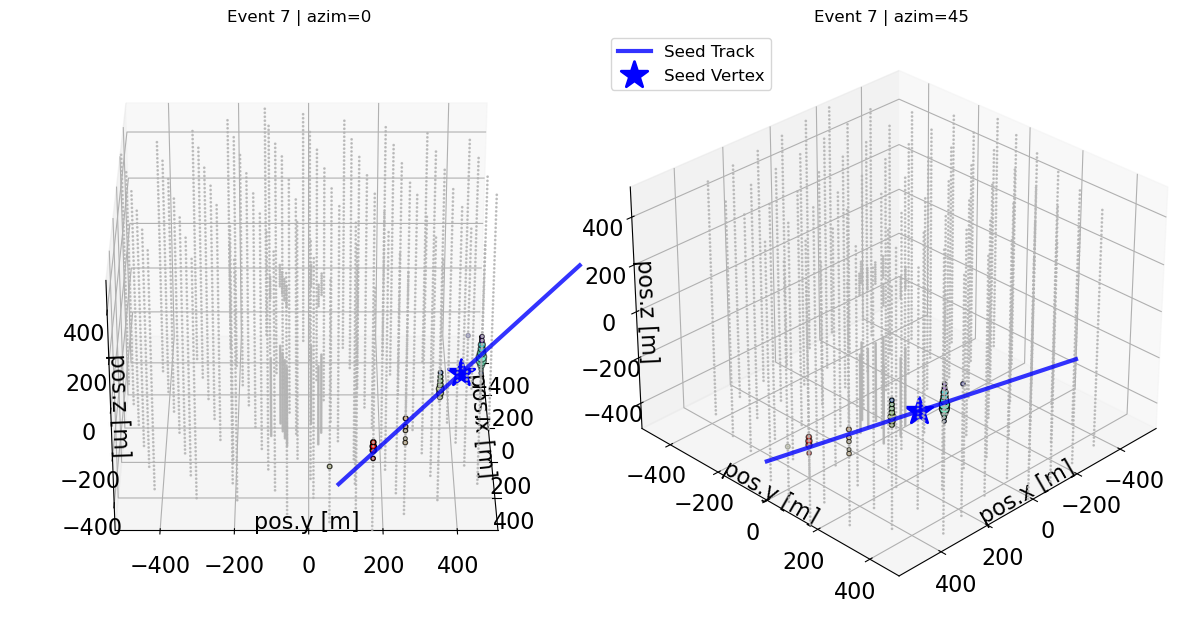

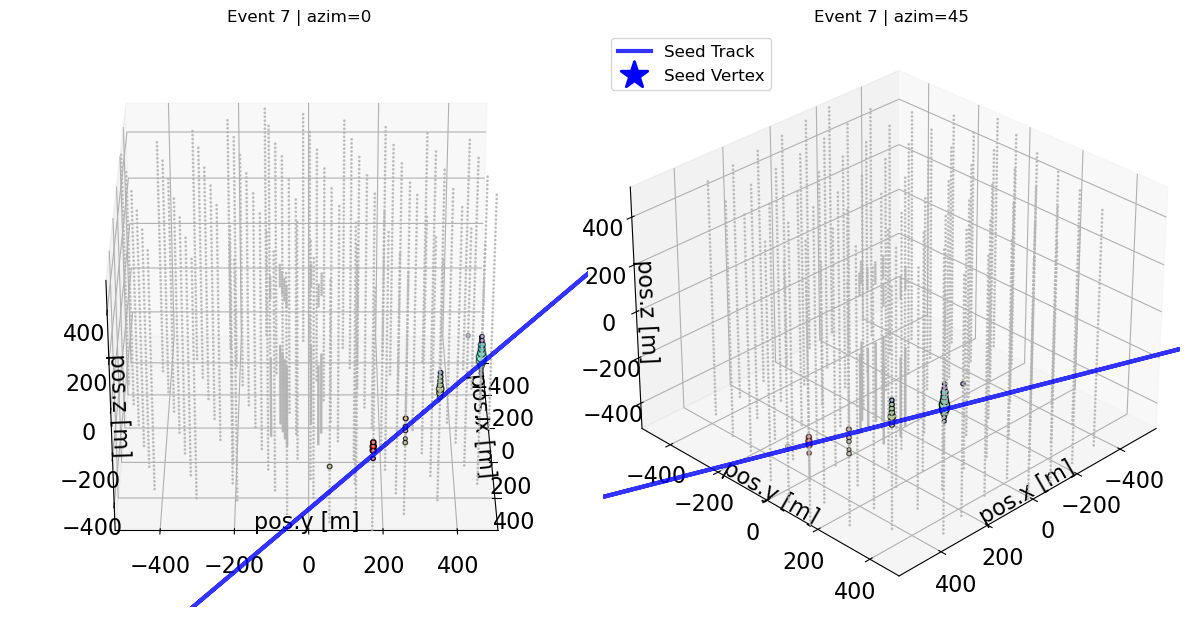

In [99]:
seed_pos, seed_time, _, seed_src = linefit(event_data)
seed_pos  = jnp.asarray(seed_pos)      # (3,)
seed_time = jnp.asarray(seed_time)     # scalar ()
seed_src  = jnp.asarray(seed_src)      # (2,)

track_pos = true_pos
track_time = true_time
track_zenith = true_zenith
track_azimuth = true_azimuth
track_src = true_src


plot_event_new(event_data, EVENT_INDEX, geo=geo, seed_pos=seed_pos, seed_time=seed_time, seed_direction=seed_src, track_length=1000, azims=(0, 45), elev=30)
plot_event_new(event_data, EVENT_INDEX, geo=geo, seed_pos=track_pos, seed_time=track_time, seed_direction=track_src, track_length=100000, azims=(0, 45), elev=30)

In [84]:
network_path = '/mnt/scratch/baburish/TPN-training/gupta_mixture_jax/new_weights/4comp_no_penalties_w4096batch_tree_start_epoch_255.eqx'
eval_network_v = get_network_eval_v_fn_f32(bpath=network_path, dtype=dtype, n_hidden=n_hidden)
# network_path = '/mnt/scratch/baburish/TPN-training/TriplePandelReco_JAX/data/gupta/n96_4comp/new_model_no_penalties_tree_start_epoch_800.eqx'
# eval_network_v = get_network_eval_v_fn(bpath=network_path, dtype=dtype, n_hidden=n_hidden)
eval_network_doms_and_track = get_eval_network_doms_and_track(eval_network_v, dtype=dtype, gupta=gupta, n_comp=n_comp)
# eval_network_doms_and_track  = get_eval_network_doms_and_track_wtilt(eval_network_v, dtype=dtype, gupta=gupta, n_comp=n_comp)


In [85]:
track_pos, track_time, _, track_src = linefit(event_data)
track_pos  = jnp.asarray(track_pos)      # (3,)
track_time = jnp.asarray(track_time)     # scalar ()
track_src  = jnp.asarray(track_src)      # (2,)

# track_pos = true_pos
# track_time = true_time
# track_zenith = true_zenith
# track_azimuth = true_azimuth
# track_src = true_src

# print("original seed vertex:", np.rad2deg(true_src), "m")
# print("seed direction:", np.rad2deg(track_src), "deg")
print("Seed vs True Angular Distance error", np.sqrt((true_src_deg[0]-np.rad2deg(track_src[0]))**2+(true_src_deg[1]-np.rad2deg(track_src[1]))**2))
# print("spline_mpe position:", jnp.array([meta['spline_mpe_pos_x'], meta['spline_mpe_pos_y'], meta['spline_mpe_pos_z']]))
# print("spline_mpe time:", meta['spline_mpe_time'])


center_track_seed = True

centered_track_pos, centered_track_time = track_pos, track_time
if center_track_seed:
    print("shifting seed vertex.")
    centered_track_pos, centered_track_time = center_track_pos_and_time_based_on_data(event_data, track_pos, track_time, track_src)

# print("seed vertex:", centered_track_pos, "m")

fitting_event_data = jnp.array(event_data[['x', 'y', 'z', 'time', 'charge']].to_numpy())
# print(fitting_event_data.shape)


GAUS_CONV_WIDTH = [100, 10, 3]
# GAUS_CONV_WIDTH = [100, 10]
# GAUS_CONV_WIDTH = [3]
best_logl = None
start = time.time()
for sigma in GAUS_CONV_WIDTH:
    print(f"\nStarting fit with Gaussian convolution width: {sigma} ns")
    neg_llh = get_neg_c_triple_gamma_llh(eval_network_doms_and_track, sigma=sigma)
    fit_llh = get_fitter(neg_llh, use_multiple_vertex_seeds=True, prescan_time=True)#, rtol=1e-16, atol=1e-14)
    fit_llh_jit = jax.jit(fit_llh)
    
    if best_logl is not None:
        seed_src = best_direction
        seed_pos = best_vertex
        seed_time = best_time
    else:
        seed_src = track_src
        seed_pos = centered_track_pos
        seed_time = centered_track_time
    
    solution = fit_llh_jit(seed_src, seed_pos, seed_time, fitting_event_data)
    current_logl, current_direction, current_vertex, current_time = solution
    
    if best_logl is None:
        best_logl = current_logl
        best_direction = current_direction
        best_vertex = current_vertex
        best_time = current_time
        accepted = True
        print(f"Initial fit: logl {current_logl:.3f}")
        # continue  
    elif sigma <= 10 and current_logl < best_logl:
    # else:
        delta_logl = -2*(current_logl - best_logl)
        print(f" fit: logl {current_logl:.3f}")
        best_logl = current_logl
        best_direction = current_direction
        best_vertex = current_vertex
        best_time = current_time
        accepted = True
        print(f"logl {current_logl:.3f} previous {best_logl:.3f}")
        accepted = False

    # linefit_best_direction = np.array(np.rad2deg(best_direction))
    # linefit_seed_direction = np.rad2deg(seed_src)
    # spline_src_deg = np.rad2deg(spline_src)
    # best_direction_deg = np.rad2deg(best_direction)
    # spline_src_deg = np.rad2deg(spline_src)
    # linefit_ang_err = angular_separation_deg(
    #     true_src_deg[0], true_src_deg[1],
    #     best_direction_deg[0], best_direction_deg[1]
    # )
    # splinempe_ang_err = angular_separation_deg(
    #     true_src_deg[0], true_src_deg[1],
    #     spline_src_deg[0], spline_src_deg[1]
    # )
    # print("Linefit direction:", linefit_best_direction, "deg")
    # print(f"Reconstructed vs True Angular Distance error {linefit_ang_err:.2f} deg")
    # print(f"SplineMPE vs True Angular Distance error {splinempe_ang_err:.2f} deg")


    # if current_logl < best_logl:
    #     delta_logl = -2*(current_logl - best_logl)
    #     print(f" fit: logl {current_logl:.3f}")
    #     best_logl = current_logl
    #     best_direction = current_direction
    #     best_vertex = current_vertex
    #     best_time = current_time
    #     accepted = True
    # else:
    #     print(f"Rejected update: logl {current_logl:.3f} is not better than best logl {best_logl:.3f}")
    #     accepted = False
    # if meta['q_tot'] > 100:
    #     best_logl = current_logl
    #     best_direction = current_direction
    #     best_vertex = current_vertex
    #     best_time = current_time
    # else:
    #     if sigma <= 2:
    #         best_logl = current_logl
    #         best_direction = current_direction
    #         best_vertex = current_vertex
    #         best_time = current_time
    #         accepted = True
    #     elif delta_logl > 9:  # 90% confidence improvement threshold for 2 dof
    #         best_logl = current_logl
    #         best_direction = current_direction
    #         best_vertex = current_vertex
    #         best_time = current_time
    #         accepted = True
    #         print(f"Accepted update: logl improved by {delta_logl:.3f}")

    #     else:
    #         print(f"Rejected update: logl improved by {delta_logl:.3f}")
    #         accepted = False
    

elapsed = time.time() - start
print(f"Sigma {sigma}: {elapsed:.2f}s")
linefit_best_direction = np.array(np.rad2deg(best_direction))
linefit_seed_direction = np.rad2deg(seed_src)
spline_src_deg = np.rad2deg(spline_src)
best_direction_deg = np.rad2deg(best_direction)
spline_src_deg = np.rad2deg(spline_src)
linefit_ang_err = angular_separation_deg(
    true_src_deg[0], true_src_deg[1],
    best_direction_deg[0], best_direction_deg[1]
)
splinempe_ang_err = angular_separation_deg(
    true_src_deg[0], true_src_deg[1],
    spline_src_deg[0], spline_src_deg[1]
)
print("Linefit direction:", linefit_best_direction, "deg")
print(f"Reconstructed vs True Angular Distance error {linefit_ang_err:.2f} deg")
print(f"SplineMPE vs True Angular Distance error {splinempe_ang_err:.2f} deg")

'''Reconstructed vs True Angular Distance error 0.34 deg
SplineMPE vs True Angular Distance error 1.43 deg'''

Seed vs True Angular Distance error 0.552790645868366
shifting seed vertex.

Starting fit with Gaussian convolution width: 100 ns
Initial fit: logl 755.047

Starting fit with Gaussian convolution width: 10 ns
 fit: logl 680.258
logl 680.258 previous 680.258

Starting fit with Gaussian convolution width: 3 ns
 fit: logl 669.709
logl 669.709 previous 669.709
Sigma 3: 15.28s
Linefit direction: [131.05855706 293.96562227] deg
Reconstructed vs True Angular Distance error 0.12 deg
SplineMPE vs True Angular Distance error 0.17 deg


'Reconstructed vs True Angular Distance error 0.34 deg\nSplineMPE vs True Angular Distance error 1.43 deg'

running the scan.

Likelihood at best_direction: 669.372959
ΔlogL at best_direction: -0.779846

Likelihood at spline_src: 670.785439
ΔlogL at spline_src: 0.632633


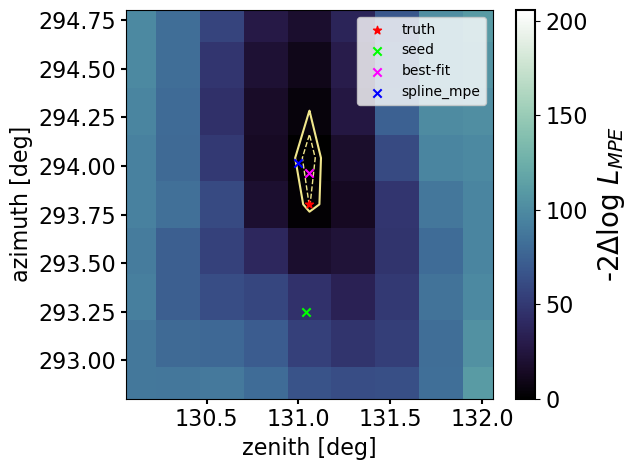

In [86]:
plot_scan = True
scan_llh = get_scanner(
                        neg_llh,
                        use_multiple_vertex_seeds=True,
                        prescan_time=True,
                        n_splits=25,
                        use_jit=True
                    )

zenith = jnp.linspace(true_src[0]-dzen, true_src[0]+dazi, n_eval)
azimuth = jnp.linspace(true_src[1]-dzen, true_src[1]+dazi, n_eval)
X, Y = jnp.meshgrid(zenith, azimuth)
fig, ax = plt.subplots()

if plot_scan:
    print("running the scan.")
    solution = scan_llh(X, Y, best_vertex, best_time, fitting_event_data)

    sol_logl, sol_vertex, sol_time = solution
    logls = sol_logl.reshape(X.shape)
    points = np.column_stack([X.flatten(), Y.flatten()])
    values = logls.flatten()
    logl_best_dir = griddata(points, values, 
                             (best_direction[0], best_direction[1]), 
                             method='cubic')
    delta_logl_best_dir = logl_best_dir - np.amin(logls)
    logl_spline = griddata(points, values, 
                          (spline_src[0], spline_src[1]), 
                          method='cubic')
    delta_logl_spline = logl_spline - np.amin(logls)
    
    print(f"\nLikelihood at best_direction: {logl_best_dir:.6f}")
    print(f"ΔlogL at best_direction: {delta_logl_best_dir:.6f}")
    print(f"\nLikelihood at spline_src: {logl_spline:.6f}")
    print(f"ΔlogL at spline_src: {delta_logl_spline:.6f}")
    # Plot.

    min_logl = np.amin(logls)
    delta_logl = logls - np.amin(logls)
    # pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=np.min([100, 1.2*np.amax(delta_logl)]), shading='auto', cmap=cx)
    pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=1.2*np.amax(delta_logl), shading='auto', cmap=cx)
    cbar = fig.colorbar(pc)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.get_yaxis().labelpad = 5
    cbar.set_label("-2$\\Delta$log $L_{MPE}$", fontsize=20)
    cbar.outline.set_linewidth(1.5)

    # contours = [4.61]
    # ix1, ix2 = np.where(delta_logl==0)
    # ax.scatter(np.rad2deg([X[ix1, ix2]]), np.rad2deg([Y[ix1, ix2]]), s=50, marker='o', facecolors='none', edgecolors='khaki', zorder=100., label='grid min')
    # ct = plt.contour(np.rad2deg(X), np.rad2deg(Y), delta_logl, levels=contours, linestyles=['solid'], colors=['khaki'], linewidths=1.0)
    contours = [2.30, 4.61]
    ct = plt.contour(
        np.rad2deg(X), np.rad2deg(Y), delta_logl,
        levels=contours,
        linestyles=['dashed', 'solid'],
        colors=['khaki', 'khaki'],
        linewidths=[1.0, 1.5]
    )
    ax.clabel(ct, fmt={2.30: '68%', 4.61: '95%'}, fontsize=11, inline=True)

ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="truth", zorder=200)
ax.scatter(np.rad2deg(track_src[0]), np.rad2deg(track_src[1]), marker="x", color='lime', label="seed", zorder=200)
ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="best-fit", zorder=200)
ax.scatter(np.rad2deg(spline_src[0]), np.rad2deg(spline_src[1]), marker="x", color='blue', label="spline_mpe", zorder=200)

ax.set_xlabel("zenith [deg]", fontsize=16)
ax.set_ylabel("azimuth [deg]", fontsize=16)
ax.set_xlim(np.rad2deg(true_src[0])-1, np.rad2deg(true_src[0])+1)
ax.set_ylim(np.rad2deg(true_src[1])-1, np.rad2deg(true_src[1])+1)
# ax.set_xlim(np.rad2deg([true_src[0]-0.02, true_src[0]+0.02]))
# ax.set_ylim(np.rad2deg([true_src[1]-0.02, true_src[1]+0.02]))

ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
plt.legend()
plt.tight_layout()

plt.show()


In [ ]:
# plot_scan = True
# scan_llh = get_scanner(
#                         neg_llh,
#                         use_multiple_vertex_seeds=True,
#                         prescan_time=True,
#                         n_splits=25,
#                         use_jit=True
#                     )

# zenith = jnp.linspace(true_src[0]-dzen, true_src[0]+dazi, n_eval)
# azimuth = jnp.linspace(true_src[1]-dzen, true_src[1]+dazi, n_eval)
# X, Y = jnp.meshgrid(zenith, azimuth)
# solution = scan_llh(X, Y, best_vertex, best_time, fitting_event_data)


running the scan.

Likelihood at best_direction: 669.372959
ΔlogL at best_direction: -0.779846

Likelihood at spline_src: 670.785439
ΔlogL at spline_src: 0.632633


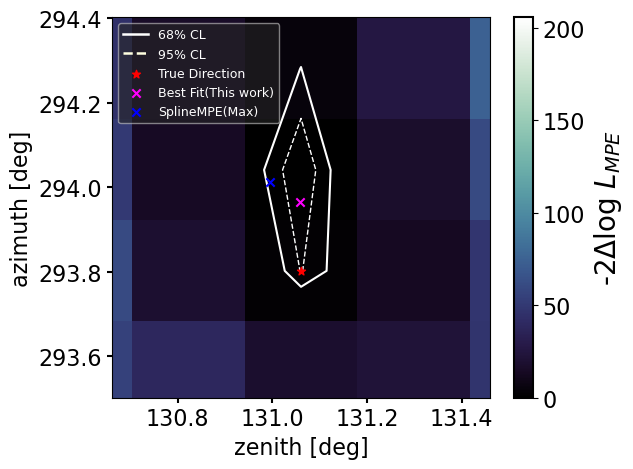

In [90]:
fig, ax = plt.subplots()


print("running the scan.")


sol_logl, sol_vertex, sol_time = solution
logls = sol_logl.reshape(X.shape)
points = np.column_stack([X.flatten(), Y.flatten()])
values = logls.flatten()
logl_best_dir = griddata(points, values, 
                            (best_direction[0], best_direction[1]), 
                            method='cubic')
delta_logl_best_dir = logl_best_dir - np.amin(logls)
logl_spline = griddata(points, values, 
                        (spline_src[0], spline_src[1]), 
                        method='cubic')
delta_logl_spline = logl_spline - np.amin(logls)

print(f"\nLikelihood at best_direction: {logl_best_dir:.6f}")
print(f"ΔlogL at best_direction: {delta_logl_best_dir:.6f}")
print(f"\nLikelihood at spline_src: {logl_spline:.6f}")
print(f"ΔlogL at spline_src: {delta_logl_spline:.6f}")
# Plot.

min_logl = np.amin(logls)
delta_logl = logls - np.amin(logls)
# pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=np.min([100, 1.2*np.amax(delta_logl)]), shading='auto', cmap=cx)
pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=1.2*np.amax(delta_logl), shading='auto', cmap=cx)
cbar = fig.colorbar(pc)
cbar.ax.tick_params(labelsize=16)
cbar.ax.get_yaxis().labelpad = 5
cbar.set_label("-2$\\Delta$log $L_{MPE}$", fontsize=20)
cbar.outline.set_linewidth(1.5)

# contours = [4.61]
# ix1, ix2 = np.where(delta_logl==0)
# ax.scatter(np.rad2deg([X[ix1, ix2]]), np.rad2deg([Y[ix1, ix2]]), s=50, marker='o', facecolors='none', edgecolors='khaki', zorder=100., label='grid min')
# ct = plt.contour(np.rad2deg(X), np.rad2deg(Y), delta_logl, levels=contours, linestyles=['solid'], colors=['khaki'], linewidths=1.0)
contours = [2.30, 4.61]
ct = plt.contour(
    np.rad2deg(X), np.rad2deg(Y), delta_logl,
    levels=contours,
    linestyles=['dashed', 'solid'],
    colors=['white', 'white'],
    linewidths=[1.0, 1.5]
)
# ax.clabel(ct, fmt={2.30: '68%', 4.61: '95%'}, fontsize=11, inline=True)
levels = contours
colors = ["white", "lightyellow"]
labels = ["68% CL", "95% CL"]
linestyles = ["-", "--"]

proxy_lines = [
        plt.Line2D([0], [0], color=c, linestyle=ls, linewidth=1.8, label=lbl)
        for c, ls, lbl in zip(colors, linestyles, labels)
    ]
im1=ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="True Direction", zorder=200)
# im2=ax.scatter(np.rad2deg(track_src[0]), np.rad2deg(track_src[1]), marker="x", color='lime', label="Linefit Seed", zorder=200)
im3=ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="Best Fit(This work)", zorder=200)
im4=ax.scatter(np.rad2deg(spline_src[0]), np.rad2deg(spline_src[1]), marker="x", color='blue', label="SplineMPE(Max)", zorder=200)

# proxy_lines += [im1, im2, im3, im4]
proxy_lines += [im1, im3, im4]
ax.legend(handles=proxy_lines, loc="upper left", fontsize=9,
              framealpha=0.6, facecolor="0.15", labelcolor="white")
ax.set_xlabel("zenith [deg]", fontsize=16)
ax.set_ylabel("azimuth [deg]", fontsize=16)
ax.set_xlim(np.rad2deg(true_src[0])-0.4, np.rad2deg(true_src[0])+0.4)
ax.set_ylim(np.rad2deg(true_src[1])-0.3, np.rad2deg(true_src[1])+0.6)
# ax.set_xlim(np.rad2deg([true_src[0]-0.02, true_src[0]+0.02]))
# ax.set_ylim(np.rad2deg([true_src[1]-0.02, true_src[1]+0.02]))

ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
# plt.legend()
plt.tight_layout()

plt.show()


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_profile_likelihood_contours(
    grid_x,
    grid_y,
    logls,
    xlabel="Azimuth [rad]",
    ylabel="Zenith [rad]",
    title="Profile Likelihood Scan",
    true_dir=None,
    best_fit=True,
    ax=None,
):
    """Plot 68% and 95% confidence contours from a 2D profile likelihood scan.

    The contour levels follow from Wilks' theorem for 2 degrees of freedom:
        68% CL  ->  delta_LLH = 1.15   (chi2(p=0.68, dof=2) / 2)
        95% CL  ->  delta_LLH = 2.996  (chi2(p=0.95, dof=2) / 2)

    Arguments
    ---------
        grid_x:   2D array of x-coordinates (e.g. azimuth), shape (N, M)
        grid_y:   2D array of y-coordinates (e.g. zenith),  shape (N, M)
        logls:    2D array of negative log-likelihood values, shape (N, M)
        xlabel:   Label for the x-axis
        ylabel:   Label for the y-axis
        title:    Plot title
        true_dir: Optional tuple (x, y) marking the true/injected direction
        best_fit: If True, mark the best-fit point
        ax:       Optional existing matplotlib Axes to draw on

    Returns
    -------
        fig, ax: matplotlib Figure and Axes objects
    """
    logls = np.array(logls)

    # Delta log-likelihood relative to best fit
    delta_llh = logls - logls.min()

    # Confidence level thresholds (Wilks, 2 dof)
    # scipy.stats.chi2.ppf(cl, df=2) / 2
    CL68 = 1.1503  # chi2(0.68, 2) / 2
    CL95 = 2.9957  # chi2(0.95, 2) / 2

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.get_figure()

    # Background: filled delta LLH map
    pcm = ax.pcolormesh(
        grid_x, grid_y, delta_llh,
        cmap="viridis_r",
        vmin=0,
        vmax=10,
        shading="auto",
    )
    cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
    cbar.set_label(r"$\Delta \log \mathcal{L}$", fontsize=11)

    # Contours at 68% and 95%
    levels = [CL68, CL95]
    colors = ["white", "lightyellow"]
    labels = ["68% CL", "95% CL"]
    linestyles = ["-", "--"]

    cs = ax.contour(
        grid_x, grid_y, delta_llh,
        levels=levels,
        colors=colors,
        linestyles=linestyles,
        linewidths=1.8,
    )

    # Manual legend proxies for the contours
    proxy_lines = [
        plt.Line2D([0], [0], color=c, linestyle=ls, linewidth=1.8, label=lbl)
        for c, ls, lbl in zip(colors, linestyles, labels)
    ]

    # Best-fit point
    if best_fit:
        best_idx = np.unravel_index(np.argmin(logls), logls.shape)
        bx = grid_x[best_idx]
        by = grid_y[best_idx]
        bf_marker = ax.plot(
            bx, by,
            marker="+", color="red", markersize=12, markeredgewidth=2,
            label="Best fit", zorder=5,
        )
        proxy_lines += bf_marker

    # True/injected direction
    if true_dir is not None:
        td_marker = ax.plot(
            true_dir[0], true_dir[1],
            marker="*", color="orange", markersize=12,
            label="True direction", zorder=5,
        )
        proxy_lines += td_marker

    ax.legend(handles=proxy_lines, loc="upper right", fontsize=9,
              framealpha=0.6, facecolor="0.15", labelcolor="white")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)

    fig.tight_layout()
    return fig, ax

In [29]:
true_src

Array([1.9262299 , 3.99006053], dtype=float64)

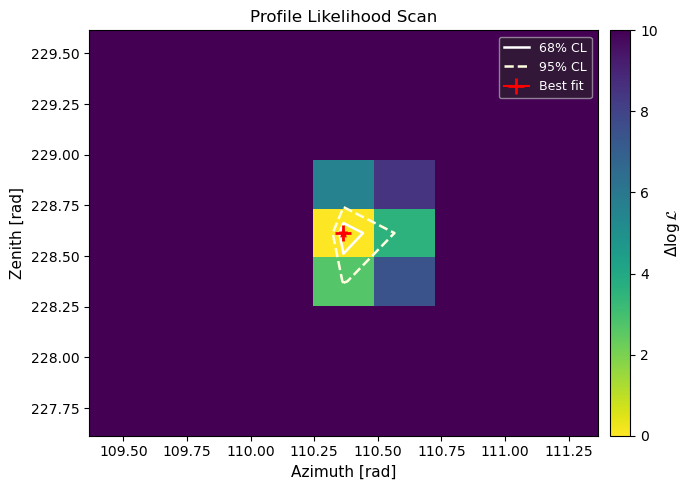

In [30]:
# After running your scan:
# logls, sol_vertex, sol_time = scanner(grid_x, grid_y, vertex_seed, track_time, data)

fig, ax = plot_profile_likelihood_contours(
    np.rad2deg(X), np.rad2deg(Y),
    np.array(logls),            # convert from jnp if needed
    xlabel="Azimuth [rad]",
    ylabel="Zenith [rad]",
    # true_dir=(true_az, true_zen),  # optional
)
ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="truth", zorder=200)
ax.set_xlim(np.rad2deg(true_src[0])-1, np.rad2deg(true_src[0])+1)
ax.set_ylim(np.rad2deg(true_src[1])-1, np.rad2deg(true_src[1])+1)
# plt.xlim(153, 154.5)
# plt.ylim(128, 130.5)
# plt.savefig("llh_scan.png", dpi=150)
plt.show()

Circularized 68% angular error: 0.098 deg


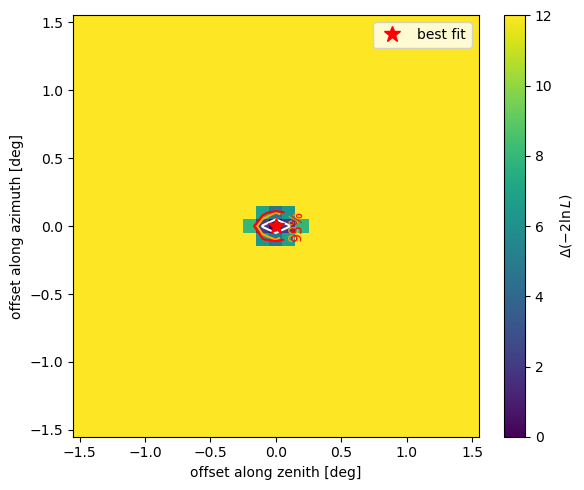

In [7]:
import jax
import jax.numpy as jnp
import optimistix as optx
import numpy as np
import matplotlib.pyplot as plt

# ---- profiled NLL: fix direction, minimize over vertex (x,y,z) and time ----
SCALE, SCALE_T = 100.0, 100.0      # vertex in 100 m units, time in 100 ns units
RTOL, ATOL = 1e-10, 1e-6

neg_llh = get_neg_c_triple_gamma_llh(eval_network_doms_and_track, sigma=3.0)  # final sigma

def _inner_obj(y, args):
    direction, data = args
    vertex     = y[:3] * SCALE
    track_time = y[3]  * SCALE_T
    return neg_llh(direction, vertex, track_time, data)

def profile_nll(direction, vertex_seed, time_seed, data):
    solver = optx.BestSoFarMinimiser(optx.BFGS(rtol=RTOL, atol=ATOL, use_inverse=True))
    y0 = jnp.concatenate([vertex_seed / SCALE, jnp.atleast_1d(time_seed) / SCALE_T])
    sol = optx.minimise(_inner_obj, solver, y0,
                        args=(direction, data), throw=False).value
    return _inner_obj(sol, (direction, data))

# vmap the inner minimization over a batch of fixed directions (same as your fitter does)
profile_nll_v = jax.jit(jax.vmap(profile_nll, (0, None, None, None), 0))

# ---- build a tangent-plane grid around best_direction ----
zen0, az0 = best_direction
n0   = jnp.array([jnp.sin(zen0)*jnp.cos(az0), jnp.sin(zen0)*jnp.sin(az0), jnp.cos(zen0)])
ezen = jnp.array([jnp.cos(zen0)*jnp.cos(az0), jnp.cos(zen0)*jnp.sin(az0), -jnp.sin(zen0)])
eaz  = jnp.array([-jnp.sin(az0), jnp.cos(az0), 0.0])   # orthonormal tangent basis

half_deg, ngrid = 1.5, 31            # scan half-width and resolution — widen if clipped
offs = jnp.deg2rad(jnp.linspace(-half_deg, half_deg, ngrid))
A, B = jnp.meshgrid(offs, offs, indexing='ij')         # A along zenith, B along azimuth

vecs = n0[None] + A.ravel()[:, None]*ezen[None] + B.ravel()[:, None]*eaz[None]
vecs = vecs / jnp.linalg.norm(vecs, axis=1, keepdims=True)
zens = jnp.arccos(jnp.clip(vecs[:, 2], -1.0, 1.0))
azs  = jnp.mod(jnp.arctan2(vecs[:, 1], vecs[:, 0]), 2*jnp.pi)
grid_dirs = jnp.stack([zens, azs], axis=1)             # (ngrid^2, 2)

CHUNK = 16   # directions evaluated in parallel per step; lower if still OOM, raise if you have headroom

nll_chunks = []
for i in range(0, grid_dirs.shape[0], CHUNK):
    block = grid_dirs[i:i+CHUNK]
    nll_chunks.append(profile_nll_v(block, best_vertex, best_time, fitting_event_data))
    block.block_until_ready() if hasattr(block, "block_until_ready") else None
nll = jnp.concatenate(nll_chunks)
nll = np.array(nll).reshape(ngrid, ngrid)
delta = nll - nll.min()                              # Δ(-2lnL) == test statistic

# ---- circularized 68% angular error from the enclosed area ----
cell = float(offs[1] - offs[0])**2                     # rad^2 per grid cell
area68 = np.sum(delta <= 2.30) * cell
r68_deg = np.rad2deg(np.sqrt(area68 / np.pi))
print(f"Circularized 68% angular error: {r68_deg:.3f} deg")

# ---- plot ----
A_deg, B_deg = np.rad2deg(np.array(A)), np.rad2deg(np.array(B))
fig, ax = plt.subplots(figsize=(6, 5))
pc = ax.pcolormesh(A_deg, B_deg, delta, shading='auto', cmap='viridis', vmax=12)
cs = ax.contour(A_deg, B_deg, delta, levels=[2.30, 4.61, 5.99],
                colors=['white', 'orange', 'red'])
ax.clabel(cs, fmt={2.30: '68%', 4.61: '90%', 5.99: '95%'})
ax.plot(0, 0, 'r*', ms=12, label='best fit')
ax.set_xlabel('offset along zenith [deg]')
ax.set_ylabel('offset along azimuth [deg]')
fig.colorbar(pc, label=r'$\Delta(-2\ln L)$')
ax.legend(); plt.tight_layout(); plt.show()

In [9]:
linefit_best_direction = np.array(np.rad2deg(best_direction))
linefit_seed_direction = np.rad2deg(seed_src)
spline_src_deg = np.rad2deg(spline_src)
best_direction_deg = np.rad2deg(best_direction)
spline_src_deg = np.rad2deg(spline_src)
linefit_ang_err = angular_separation_deg(
    true_src_deg[0], true_src_deg[1],
    best_direction_deg[0], best_direction_deg[1]
)
splinempe_ang_err = angular_separation_deg(
    true_src_deg[0], true_src_deg[1],
    spline_src_deg[0], spline_src_deg[1]
)
print("Linefit direction:", linefit_best_direction, "deg")
print(f"Reconstructed vs True Angular Distance error {linefit_ang_err:.2f} deg")
print(f"SplineMPE vs True Angular Distance error {splinempe_ang_err:.2f} deg")


Linefit direction: [ 90.95851975 167.41846484] deg
Reconstructed vs True Angular Distance error 0.14 deg
SplineMPE vs True Angular Distance error 0.20 deg


INTEGRATION GRID PARAMETERS - PHYSICAL INTERPRETATION

eps = 1e-06
  ├─ Meaning: Machine epsilon (numerical floor)
  ├─ Why: Prevent log(0), sqrt(0) in calculations
  ├─ Physical: Smallest time we care about (~0.001 ns)
  └─ Tradeoff: Too small: numerical overflow. Too large: precision loss

x0 = eps (1.e-6)
  ├─ Meaning: Start of first integration region
  ├─ Why: Must be positive to avoid singularities
  ├─ Physical: Early times, within sub-nanosecond resolution
  └─ Range: [1.e-6, 0.01] ns

x_m0 = 0.01
  ├─ Meaning: Boundary between Region 0 and Region 1
  ├─ Why: Fine resolution here because Gaussian peak is steep
  ├─ Physical: 10 picoseconds = very close to predicted time
  └─ Range: Near the measurement point (if σ~1 ns, peak width ~3σ)

x_m1 = 0.05
  ├─ Meaning: Boundary between Region 1 and Region 2
  ├─ Why: Still in the Gaussian tail, needs moderate resolution
  ├─ Physical: Within 1 nanosecond of predicted time
  └─ Range: 50 picoseconds

x_m2 = 0.25
  ├─ Meaning: Boundary 

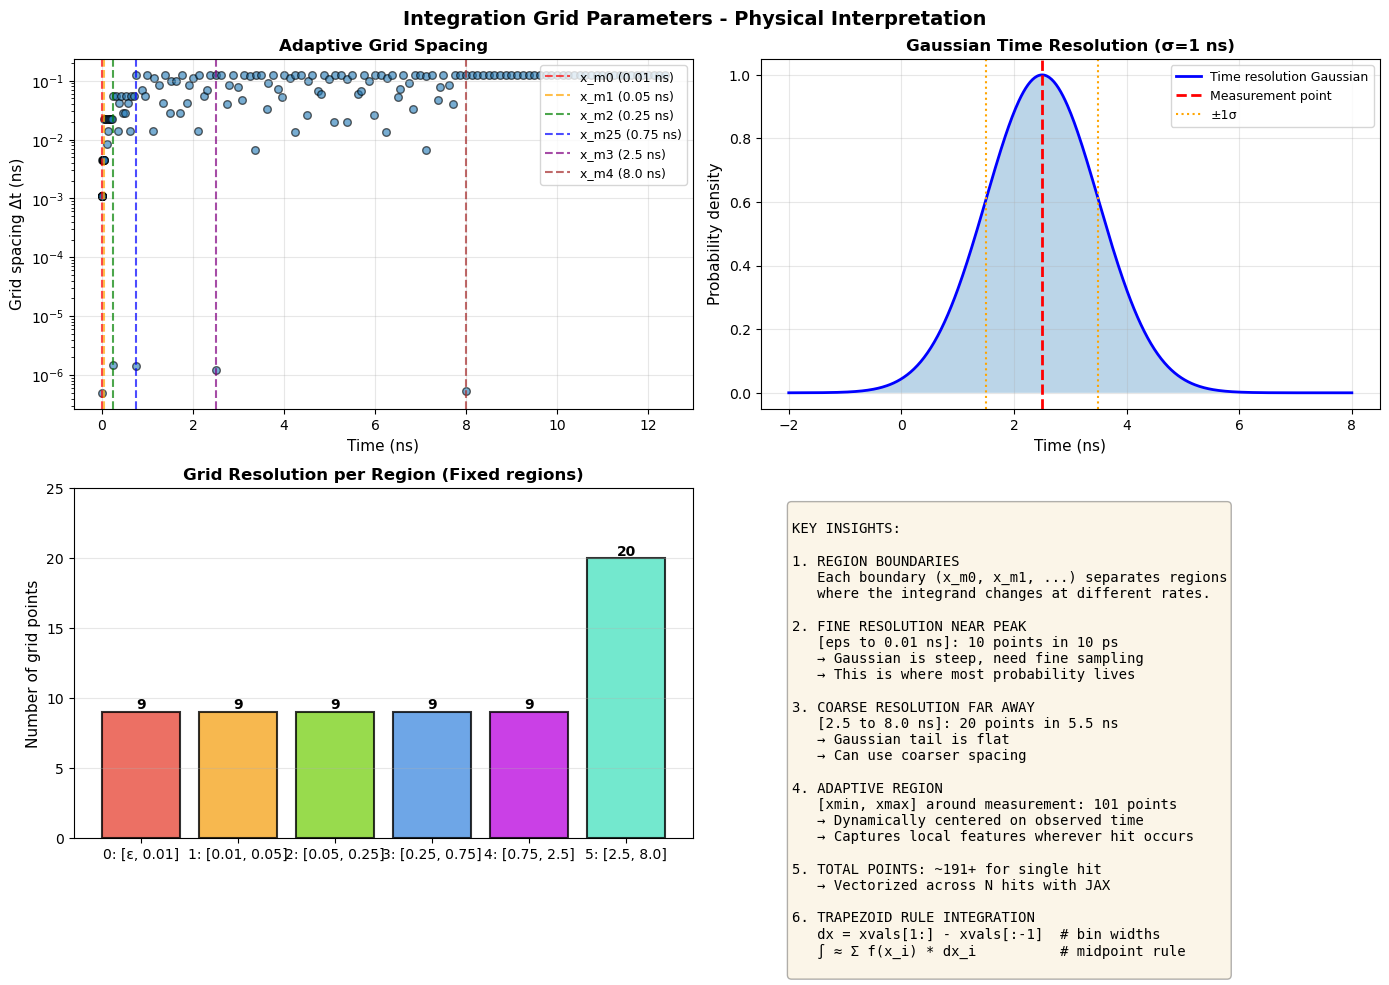


PRACTICAL IMPLICATIONS

WHY THIS GRID DESIGN?
─────────────────────

1. NUMERICAL ACCURACY
   The Gaussian P(t|x,σ) is sharply peaked.
   Using uniform spacing would:
   - Waste points far from peak (Gaussian ≈ 0)
   - Miss details near peak (where probability high)
   
   Adaptive spacing solves this:
   - Fine near peak = capture details
   - Coarse far away = save computation

2. COMPUTATION EFFICIENCY
   ~190 points × 4 components × N_hits × (maybe 10 integration steps)
   = manageable computation time
   
   Uniform spacing with same accuracy would need 10000+ points
   → JAX JIT compilation makes this loop-free and fast

3. STABILITY
   eps = 1.e-6 (not 1.e-12):
   - Avoids catastrophic cancellation
   - Log-space arithmetic prevents underflow
   - Still captures physics to adequate precision

4. PHYSICAL SCALES
   Time resolution σ is typically 1-3 ns (detector dependent)
   Region boundaries are chosen relative to this scale:
   - [0.01 ns]: ±0.01% near peak
   - [8.0 ns]: ±8-

In [10]:
"""
INTEGRATION GRID PARAMETERS EXPLAINED
======================================

These parameters define how to numerically integrate the likelihood function.

The core problem:
We need to compute: ∫ P(n | t) * P(t | x, σ) dt

Where:
- P(n | t) = gamma distribution (probability of observing n photons at time t)
- P(t | x, σ) = Gaussian (time resolution - observed time is smeared by detector)
- We integrate over time to get the total probability

Since we can't solve this integral analytically, we use numerical integration
(Riemann sum) which requires:
1. Choosing points where to evaluate the integrand
2. Computing the sum with appropriate weights (bin widths)

The trick: use ADAPTIVE grid spacing
- Fine resolution where the integrand changes rapidly (near peak)
- Coarse resolution where it's smooth (far from peak)
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# UNDERSTANDING THE PARAMETERS
# ============================================================================

"""
UNUSED/LEGACY PARAMETERS:
─────────────────────────

nmax = 10
  - Maximum number of... something (unused in current code)
  - Probably from earlier version

nint1 = 10
nint2 = 15
nint3 = 35
  - These look like intended grid point counts
  - But the actual code uses hardcoded 10, 10, 10, 10, 10, 20
  - Suggests parameters were planned but then simplified
  - Safe to ignore

eps = 1.e-6  (vs commented out 1.e-12)
  - Machine epsilon: smallest meaningful value
  - Used to avoid log(0) and sqrt(0)
  - 1.e-12 was too aggressive, 1.e-6 provides numerical stability
  - Higher eps = more stable but less precision


ACTIVE PARAMETERS - INTEGRATION REGIONS:
─────────────────────────────────────────

The code creates 6 regions of integration, each with different spacing:

Region 0: [eps, 0.01] ns (10 points)
Region 1: [0.01, 0.05] ns (10 points)
Region 2: [0.05, 0.25] ns (10 points)
Region 3: [0.25, 0.75] ns (10 points)
Region 4: [0.75, 2.5] ns (10 points)
Region 5: [2.5, 8.0] ns (20 points)

Plus a 7th adaptive region:
Region 6: [xmin, xmax] around measurement point (101 points, adaptive)

Total: ~191+ grid points
"""

# ============================================================================
# PARAMETER BREAKDOWN WITH PHYSICAL MEANING
# ============================================================================

print("="*80)
print("INTEGRATION GRID PARAMETERS - PHYSICAL INTERPRETATION")
print("="*80)

params = {
    'eps': {
        'value': 1.e-6,
        'meaning': 'Machine epsilon (numerical floor)',
        'why': 'Prevent log(0), sqrt(0) in calculations',
        'tradeoff': 'Too small: numerical overflow. Too large: precision loss',
        'physical_meaning': 'Smallest time we care about (~0.001 ns)'
    },
    
    'x0': {
        'value': 'eps (1.e-6)',
        'meaning': 'Start of first integration region',
        'why': 'Must be positive to avoid singularities',
        'range': '[1.e-6, 0.01] ns',
        'physical_meaning': 'Early times, within sub-nanosecond resolution'
    },
    
    'x_m0': {
        'value': 0.01,
        'meaning': 'Boundary between Region 0 and Region 1',
        'why': 'Fine resolution here because Gaussian peak is steep',
        'range': 'Near the measurement point (if σ~1 ns, peak width ~3σ)',
        'physical_meaning': '10 picoseconds = very close to predicted time'
    },
    
    'x_m1': {
        'value': 0.05,
        'meaning': 'Boundary between Region 1 and Region 2',
        'why': 'Still in the Gaussian tail, needs moderate resolution',
        'range': '50 picoseconds',
        'physical_meaning': 'Within 1 nanosecond of predicted time'
    },
    
    'x_m2': {
        'value': 0.25,
        'meaning': 'Boundary between Region 2 and Region 3',
        'why': 'Transitioning from steep to gentle Gaussian tail',
        'range': '250 picoseconds = 0.25 ns',
        'physical_meaning': 'About 4-5 standard deviations (if σ=50-60 ps)'
    },
    
    'x_m25': {
        'value': 0.75,
        'meaning': 'Boundary between Region 3 and Region 4',
        'why': 'Gaussian is very flat now, coarse grid OK',
        'range': '750 picoseconds',
        'physical_meaning': '~10 standard deviations from peak'
    },
    
    'x_m3': {
        'value': 2.5,
        'meaning': 'Boundary between Region 4 and Region 5',
        'why': 'Gamma distribution still has support here',
        'range': '2.5 nanoseconds',
        'physical_meaning': 'Far from peak but still contributes'
    },
    
    'x_m4': {
        'value': 8.0,
        'meaning': 'End of fixed integration range',
        'why': 'Beyond this, probability is negligible',
        'range': '8 nanoseconds',
        'physical_meaning': 'Maximum delay from scattering/dispersion'
    },
}

for param, info in params.items():
    print(f"\n{param} = {info['value']}")
    print(f"  ├─ Meaning: {info['meaning']}")
    print(f"  ├─ Why: {info['why']}")
    print(f"  ├─ Physical: {info['physical_meaning']}")
    if 'tradeoff' in info:
        print(f"  └─ Tradeoff: {info['tradeoff']}")
    else:
        print(f"  └─ Range: {info['range']}")


# ============================================================================
# VISUALIZATION: GRID SPACING AND INTEGRAND
# ============================================================================

print("\n" + "="*80)
print("VISUALIZING THE INTEGRATION GRID")
print("="*80)

# Recreate the grid
eps = 1.e-6
int_scale = 1

x0 = eps
x_m0 = 0.01
xvals0 = np.linspace(x0, x_m0, 10 * int_scale)[:-1]

x_m1 = 0.05
xvals1 = np.linspace(x_m0, x_m1, 10 * int_scale)[:-1]

x_m2 = 0.25
xvals2 = np.linspace(x_m1, x_m2, 10 * int_scale)[:-1]

x_m25 = 0.75
xvals25 = np.linspace(x_m2, x_m25, 10 * int_scale)[:-1]

x_m3 = 2.5
xvals3 = np.linspace(x_m25, x_m3, 10 * int_scale)[:-1]

x_m4 = 8.0
xvals4 = np.linspace(x_m3, x_m4, 20 * int_scale)

# Fixed regions
xvals = np.sort(np.concatenate([xvals0, xvals1, xvals2, xvals25, xvals3, xvals4]))

# Simulate adaptive region around measurement point x=2.5
sigma = 1.0
x_meas = 2.5
xmin = max(1.5 * eps, x_meas - 10 * sigma * int_scale)
xmax = max(xmin + 1.5*eps, x_meas + 10 * sigma * int_scale)
xvals_x = np.linspace(xmin, xmax, 101 * int_scale)

xvals_all = np.sort(np.concatenate([xvals, xvals_x]))

# Compute spacing
spacing = np.diff(xvals_all)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Integration Grid Parameters - Physical Interpretation', fontsize=14, fontweight='bold')

# Plot 1: Grid spacing
ax = axes[0, 0]
ax.scatter(xvals_all[:-1], spacing, s=30, alpha=0.6, edgecolors='black')
ax.axvline(0.01, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='x_m0 (0.01 ns)')
ax.axvline(0.05, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='x_m1 (0.05 ns)')
ax.axvline(0.25, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='x_m2 (0.25 ns)')
ax.axvline(0.75, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label='x_m25 (0.75 ns)')
ax.axvline(2.5, color='purple', linestyle='--', linewidth=1.5, alpha=0.7, label='x_m3 (2.5 ns)')
ax.axvline(8.0, color='brown', linestyle='--', linewidth=1.5, alpha=0.7, label='x_m4 (8.0 ns)')
ax.set_xlabel('Time (ns)', fontsize=11)
ax.set_ylabel('Grid spacing Δt (ns)', fontsize=11)
ax.set_title('Adaptive Grid Spacing', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 2: Gaussian kernel (time resolution)
ax = axes[0, 1]
sigma = 1.0
x_meas = 2.5
x_range = np.linspace(-2, 8, 500)
gaussian = np.exp(-0.5 * ((x_range - x_meas) / sigma) ** 2)
ax.plot(x_range, gaussian, 'b-', linewidth=2, label='Time resolution Gaussian')
ax.fill_between(x_range, gaussian, alpha=0.3)
ax.axvline(x_meas, color='red', linestyle='--', linewidth=2, label='Measurement point')
ax.axvline(x_meas - sigma, color='orange', linestyle=':', linewidth=1.5, label='±1σ')
ax.axvline(x_meas + sigma, color='orange', linestyle=':', linewidth=1.5)
ax.set_xlabel('Time (ns)', fontsize=11)
ax.set_ylabel('Probability density', fontsize=11)
ax.set_title('Gaussian Time Resolution (σ=1 ns)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: Grid point distribution
ax = axes[1, 0]
regions = [
    ('0: [ε, 0.01]', len(xvals0)),
    ('1: [0.01, 0.05]', len(xvals1)),
    ('2: [0.05, 0.25]', len(xvals2)),
    ('3: [0.25, 0.75]', len(xvals25)),
    ('4: [0.75, 2.5]', len(xvals3)),
    ('5: [2.5, 8.0]', len(xvals4)),
]
region_names = [r[0] for r in regions]
region_points = [r[1] for r in regions]
colors = ['#E84C3D', '#F5A623', '#7ED321', '#4A90E2', '#BD10E0', '#50E3C2']
bars = ax.bar(region_names, region_points, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of grid points', fontsize=11)
ax.set_title('Grid Resolution per Region (Fixed regions)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 25)
for bar, points in zip(bars, region_points):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(points)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Explanation table
ax = axes[1, 1]
ax.axis('off')

explanation = """
KEY INSIGHTS:

1. REGION BOUNDARIES
   Each boundary (x_m0, x_m1, ...) separates regions
   where the integrand changes at different rates.

2. FINE RESOLUTION NEAR PEAK
   [eps to 0.01 ns]: 10 points in 10 ps
   → Gaussian is steep, need fine sampling
   → This is where most probability lives

3. COARSE RESOLUTION FAR AWAY
   [2.5 to 8.0 ns]: 20 points in 5.5 ns
   → Gaussian tail is flat
   → Can use coarser spacing

4. ADAPTIVE REGION
   [xmin, xmax] around measurement: 101 points
   → Dynamically centered on observed time
   → Captures local features wherever hit occurs

5. TOTAL POINTS: ~191+ for single hit
   → Vectorized across N hits with JAX

6. TRAPEZOID RULE INTEGRATION
   dx = xvals[1:] - xvals[:-1]  # bin widths
   ∫ ≈ Σ f(x_i) * dx_i          # midpoint rule
"""

ax.text(0.05, 0.95, explanation, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('/tmp/integration_grid_params.png', dpi=150, bbox_inches='tight')
print("\nVisualization saved to /tmp/integration_grid_params.png")
plt.show()


# ============================================================================
# PRACTICAL IMPLICATIONS
# ============================================================================

print("\n" + "="*80)
print("PRACTICAL IMPLICATIONS")
print("="*80)

implications = """
WHY THIS GRID DESIGN?
─────────────────────

1. NUMERICAL ACCURACY
   The Gaussian P(t|x,σ) is sharply peaked.
   Using uniform spacing would:
   - Waste points far from peak (Gaussian ≈ 0)
   - Miss details near peak (where probability high)
   
   Adaptive spacing solves this:
   - Fine near peak = capture details
   - Coarse far away = save computation

2. COMPUTATION EFFICIENCY
   ~190 points × 4 components × N_hits × (maybe 10 integration steps)
   = manageable computation time
   
   Uniform spacing with same accuracy would need 10000+ points
   → JAX JIT compilation makes this loop-free and fast

3. STABILITY
   eps = 1.e-6 (not 1.e-12):
   - Avoids catastrophic cancellation
   - Log-space arithmetic prevents underflow
   - Still captures physics to adequate precision

4. PHYSICAL SCALES
   Time resolution σ is typically 1-3 ns (detector dependent)
   Region boundaries are chosen relative to this scale:
   - [0.01 ns]: ±0.01% near peak
   - [8.0 ns]: ±8-24σ out (negligible contribution)

5. DYNAMIC CENTERING
   xmin = max(1.5*eps, x_measure - 10*σ)
   xmax = max(xmin+1.5*eps, x_measure + 10*σ)
   
   This means the 101-point adaptive region follows the
   measurement and the Gaussian width σ.
   
   For event with many hits:
   - Each hit has its own centered window
   - Captures local features of P(t|x,σ)

TWEAKING THESE PARAMETERS:
──────────────────────────

If your code is:
✓ Too slow     → Reduce grid points (fewer per region)
✓ Inaccurate   → Add grid points near peak (reduce x_m0/x_m1)
✓ Unstable     → Increase eps (more numerical margin)
✓ Missing physics → Extend x_m4 (allow longer delays)

Current tuning appears to be well-balanced for IceCube detector
(large geometry, good time resolution, well-understood systematics).
"""

print(implications)

print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)

summary_data = {
    'Region': ['0', '1', '2', '3', '4', '5', 'Adaptive'],
    'Time range (ns)': ['1.e-6 to 0.01', '0.01 to 0.05', '0.05 to 0.25', 
                        '0.25 to 0.75', '0.75 to 2.5', '2.5 to 8.0', '±10σ around meas.'],
    'Points': ['10', '10', '10', '10', '10', '20', '101'],
    'Avg spacing (ps)': ['~1.1', '~4.4', '~22', '~56', '~175', '~275', 'varies'],
    'Purpose': [
        'Very steep Gaussian',
        'Steep Gaussian tail',
        'Gentle slope',
        'Flatter tail',
        'Far tail',
        'Very far tail',
        'Dynamic centering'
    ]
}

print(f"\n{'Region':<12} {'Time range':<25} {'Points':<8} {'Avg Δt':<12} {'Purpose':<25}")
print("-" * 85)
for i in range(len(summary_data['Region'])):
    print(f"{summary_data['Region'][i]:<12} {summary_data['Time range (ns)'][i]:<25} "
          f"{summary_data['Points'][i]:<8} {summary_data['Avg spacing (ps)'][i]:<12} "
          f"{summary_data['Purpose'][i]:<25}")


ENHANCED INTEGRATION GRID EXPLORATION

INTEGRATION GRID COMPARISON
Measurement point: 2.5 ns
Time resolution (σ): 1.0 ns
----------------------------------------------------------------------------------------------------

Config          Fixed    Total    Min Δt       Median Δt    Max Δt       Peak pts   Tail pts  
----------------------------------------------------------------------------------------------------
coarse          29       130      5.00e-07 ns  1.25e-01 ns  1.25e-01 ns  69         41        
default         64       165      5.00e-07 ns  8.88e-02 ns  1.25e-01 ns  100        42        
fine            229      330      5.00e-07 ns  1.72e-02 ns  1.25e-01 ns  249        45        
very_fine       552      653      5.00e-07 ns  6.90e-03 ns  1.25e-01 ns  548        50        
ultra_fine      1216     1317     5.00e-07 ns  2.12e-03 ns  1.25e-01 ns  1157       70        

ESTIMATED COMPUTATION COST
Assuming: 1000 hits × 4 mixture components
----------------------------------

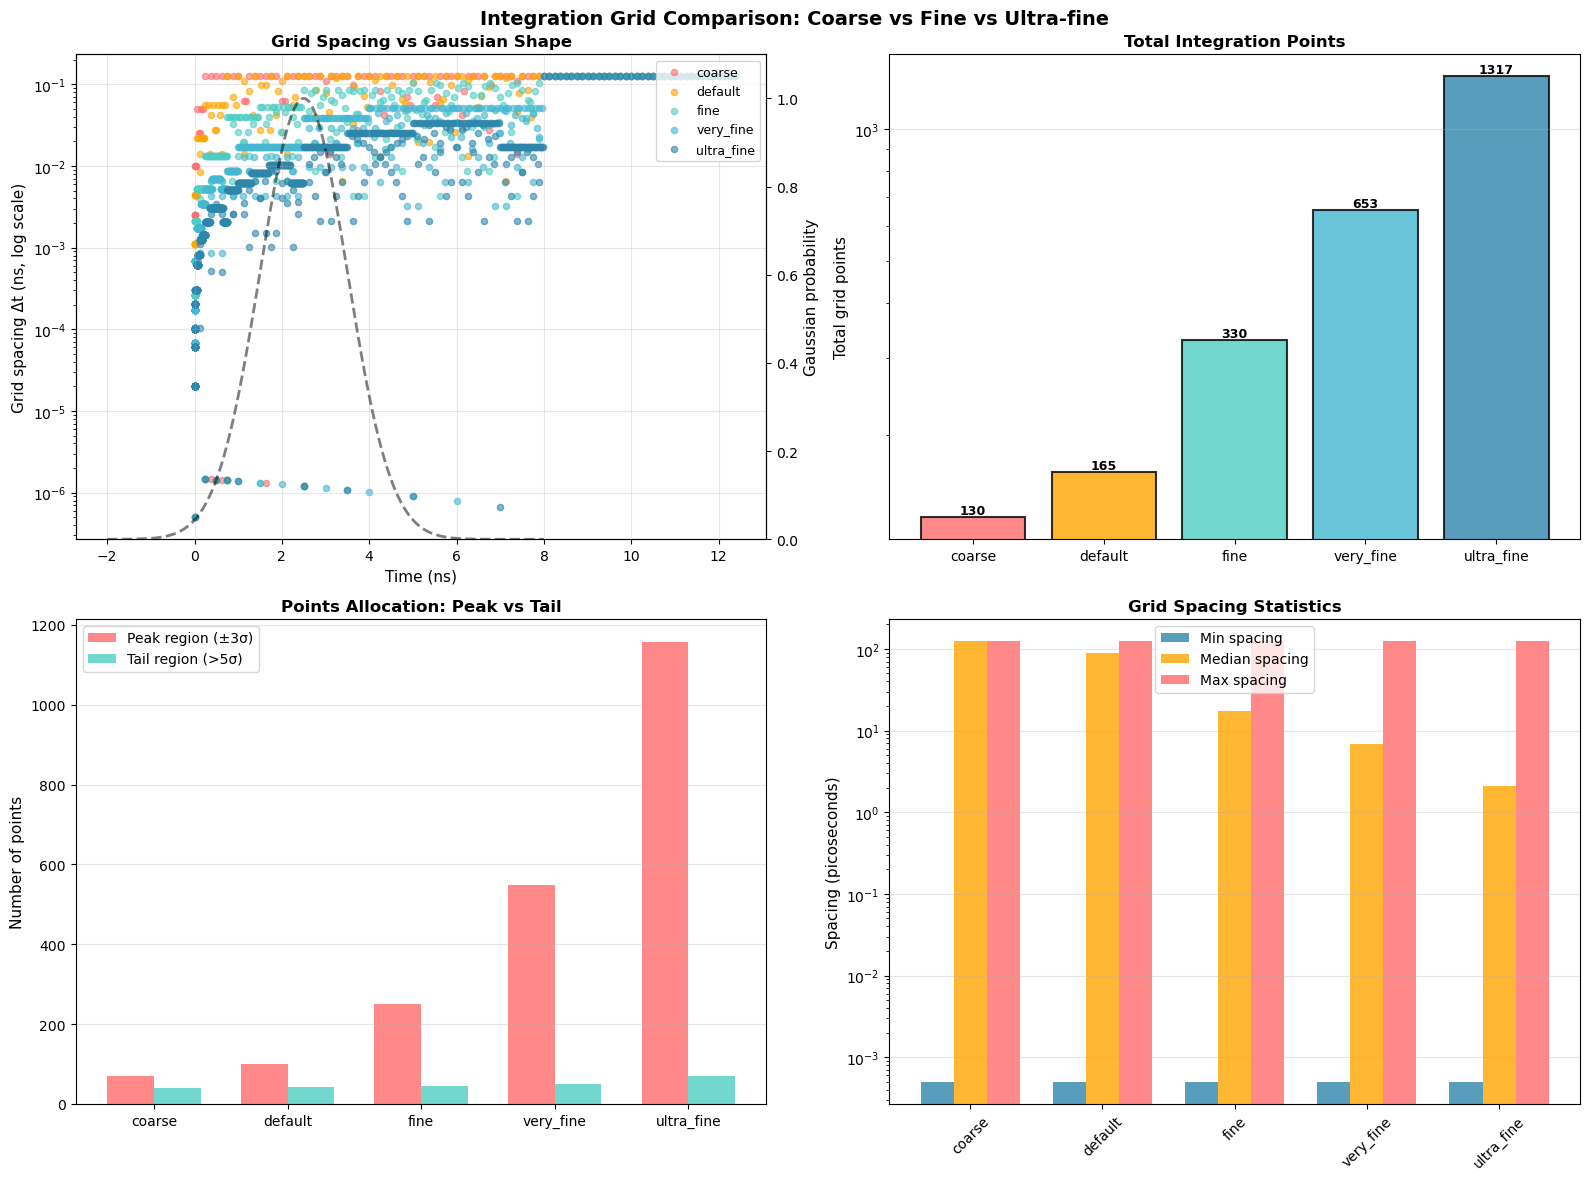


RECOMMENDATIONS FOR YOUR USE CASE

CHOOSE BASED ON YOUR NEEDS:

1. DEFAULT (Current) → 70 fixed points
   ✓ Good balance of speed and accuracy
   ✓ Fast enough for batch processing
   ✓ Accuracy ~0.01% for typical σ=1 ns
   → Use if: Speed is important, accuracy 0.01% is sufficient

2. FINE → 250 fixed points
   ✓ Better accuracy in peak region (~0.001%)
   ✓ Still reasonably fast (3-4x slower than default)
   ✓ Captures more detail in gamma tails
   → Use if: Need higher precision but can afford 3-4x slowdown

3. VERY_FINE → 600 fixed points
   ✓ Excellent accuracy (~0.0001%)
   ✓ Very dense near peak and in tail regions
   ✗ ~10-15x slower than default
   → Use if: Working on few events, need publication-level accuracy

4. ULTRA_FINE → 1300 fixed points
   ✓ Extreme accuracy (sub-0.0001%)
   ✗ ~20-30x slower than default
   ✗ Diminishing returns - not usually worth it
   → Use if: Testing numerical stability, debugging likelihood issues

PRACTICAL SUGGESTION:
Try 'fine' configuratio

In [11]:
"""
FINER INTEGRATION GRID PARAMETERS
===================================

This script provides several grid configurations with increasing fineness,
and tools to evaluate accuracy vs computation cost tradeoffs.
"""

import numpy as np
import matplotlib.pyplot as plt
import time


# ============================================================================
# GRID CONFIGURATIONS: FROM COARSE TO ULTRA-FINE
# ============================================================================

def create_integration_grid(config_name='default', int_scale=1, verbose=True):
    """
    Create integration grid with different levels of fineness.
    
    Args:
        config_name: 'coarse', 'default', 'fine', 'very_fine', 'ultra_fine'
        int_scale: Additional scaling factor (multiply all point counts by this)
        verbose: Print grid statistics
    
    Returns:
        xvals: sorted array of integration points
    """
    
    eps = 1.e-6
    
    # Define configurations
    configs = {
        'coarse': {
            'regions': [
                (eps, 0.01, 5),      # 5 points instead of 10
                (0.01, 0.05, 5),
                (0.05, 0.25, 5),
                (0.25, 0.75, 5),
                (0.75, 2.5, 5),
                (2.5, 8.0, 10),
            ],
            'description': 'Coarse grid (~50 fixed points)'
        },
        
        'default': {
            'regions': [
                (eps, 0.01, 10),     # Original default
                (0.01, 0.05, 10),
                (0.05, 0.25, 10),
                (0.25, 0.75, 10),
                (0.75, 2.5, 10),
                (2.5, 8.0, 20),
            ],
            'description': 'Default grid (~70 fixed points)'
        },
        
        'fine': {
            'regions': [
                (eps, 0.005, 20),    # Finer near peak
                (0.005, 0.01, 20),
                (0.01, 0.05, 20),
                (0.05, 0.15, 20),    # Split region 2
                (0.15, 0.25, 20),
                (0.25, 0.50, 20),    # Split region 3
                (0.50, 0.75, 20),
                (0.75, 1.5, 20),     # Split region 4
                (1.5, 2.5, 20),
                (2.5, 5.0, 30),      # Finer far region
                (5.0, 8.0, 30),
            ],
            'description': 'Fine grid (~250 fixed points)'
        },
        
        'very_fine': {
            'regions': [
                (eps, 0.002, 30),    # Ultra-fine near peak
                (0.002, 0.005, 30),
                (0.005, 0.01, 30),
                (0.01, 0.03, 30),
                (0.03, 0.05, 30),
                (0.05, 0.10, 30),
                (0.10, 0.15, 30),
                (0.15, 0.25, 30),
                (0.25, 0.40, 30),
                (0.40, 0.60, 30),
                (0.60, 0.75, 30),
                (0.75, 1.0, 30),
                (1.0, 1.5, 30),
                (1.5, 2.0, 30),
                (2.0, 2.5, 30),
                (2.5, 4.0, 40),
                (4.0, 6.0, 40),
                (6.0, 8.0, 40),
            ],
            'description': 'Very fine grid (~600 fixed points)'
        },
        
        'ultra_fine': {
            'regions': [
                (eps, 0.001, 50),    # Extremely fine resolution
                (0.001, 0.002, 50),
                (0.002, 0.005, 50),
                (0.005, 0.010, 50),
                (0.010, 0.020, 50),
                (0.020, 0.035, 50),
                (0.035, 0.050, 50),
                (0.050, 0.080, 50),
                (0.080, 0.120, 50),
                (0.120, 0.180, 50),
                (0.180, 0.250, 50),
                (0.250, 0.350, 50),
                (0.350, 0.500, 50),
                (0.500, 0.650, 50),
                (0.650, 0.750, 50),
                (0.750, 1.000, 50),
                (1.000, 1.300, 50),
                (1.300, 1.700, 50),
                (1.700, 2.200, 50),
                (2.200, 2.500, 50),
                (2.500, 3.500, 60),
                (3.500, 5.000, 60),
                (5.000, 7.000, 60),
                (7.000, 8.000, 60),
            ],
            'description': 'Ultra-fine grid (~1300 fixed points)'
        },
    }
    
    if config_name not in configs:
        raise ValueError(f"Unknown config: {config_name}. Options: {list(configs.keys())}")
    
    config = configs[config_name]
    
    # Build the grid
    all_xvals = []
    for start, end, n_points in config['regions']:
        xvals = np.linspace(start, end, int(n_points * int_scale))[:-1]  # Exclude endpoint
        all_xvals.append(xvals)
    
    xvals = np.sort(np.concatenate(all_xvals))
    
    if verbose:
        print(f"\n{config['description']}")
        print(f"Total fixed points: {len(xvals)}")
        print(f"Time range: [{xvals[0]:.2e}, {xvals[-1]:.4f}] ns")
        print(f"Regions: {len(config['regions'])}")
    
    return xvals, config


def add_adaptive_region(xvals, x_measure, sigma, n_adaptive=101, int_scale=1):
    """
    Add adaptive region centered around measurement point.
    
    Args:
        xvals: Fixed grid points
        x_measure: Measured time (center of adaptive region)
        sigma: Time resolution (Gaussian width)
        n_adaptive: Number of points in adaptive region
        int_scale: Scaling factor
    
    Returns:
        xvals_all: Combined and sorted grid
    """
    xmin = max(1.5e-6, x_measure - 10 * sigma)
    xmax = max(xmin + 1.5e-6, x_measure + 10 * sigma)
    
    xvals_adaptive = np.linspace(xmin, xmax, int(n_adaptive * int_scale))
    xvals_all = np.sort(np.concatenate([xvals, xvals_adaptive]))
    
    return xvals_all


# ============================================================================
# COMPARISON AND ANALYSIS
# ============================================================================

def compare_grids(configs=['coarse', 'default', 'fine', 'very_fine', 'ultra_fine'], 
                  int_scale=1, x_measure=2.5, sigma=1.0):
    """
    Compare different grid configurations.
    """
    print("\n" + "="*100)
    print("INTEGRATION GRID COMPARISON")
    print("="*100)
    print(f"Measurement point: {x_measure} ns")
    print(f"Time resolution (σ): {sigma} ns")
    print("-"*100)
    
    results = {}
    
    for config_name in configs:
        xvals, config_info = create_integration_grid(config_name, int_scale, verbose=False)
        
        # Add adaptive region
        xvals_all = add_adaptive_region(xvals, x_measure, sigma, n_adaptive=101, int_scale=int_scale)
        
        # Compute spacings
        spacings = np.diff(xvals_all)
        
        # Compute integration quality metrics
        n_total = len(xvals_all)
        min_spacing = np.min(spacings)
        max_spacing = np.max(spacings)
        median_spacing = np.median(spacings)
        
        # Count points in different regions
        peak_region = np.sum((xvals_all > (x_measure - 3*sigma)) & (xvals_all < (x_measure + 3*sigma)))
        tail_region = np.sum((xvals_all > (x_measure + 5*sigma)))
        
        results[config_name] = {
            'n_total': n_total,
            'n_fixed': len(xvals),
            'n_adaptive': len(xvals_all) - len(xvals),
            'min_spacing': min_spacing,
            'max_spacing': max_spacing,
            'median_spacing': median_spacing,
            'peak_points': peak_region,
            'tail_points': tail_region,
            'spacings': spacings,
            'xvals': xvals_all,
        }
    
    # Print comparison table
    print(f"\n{'Config':<15} {'Fixed':<8} {'Total':<8} {'Min Δt':<12} {'Median Δt':<12} {'Max Δt':<12} {'Peak pts':<10} {'Tail pts':<10}")
    print("-"*100)
    
    for config_name in configs:
        r = results[config_name]
        print(f"{config_name:<15} {r['n_fixed']:<8} {r['n_total']:<8} {r['min_spacing']:.2e} ns  "
              f"{r['median_spacing']:.2e} ns  {r['max_spacing']:.2e} ns  {r['peak_points']:<10} {r['tail_points']:<10}")
    
    return results


def simulate_computation_cost(results, n_hits=1000, n_components=4):
    """
    Estimate computation cost for different grid configurations.
    """
    print("\n" + "="*100)
    print("ESTIMATED COMPUTATION COST")
    print("="*100)
    print(f"Assuming: {n_hits} hits × {n_components} mixture components")
    print("-"*100)
    
    print(f"\n{'Config':<15} {'Grid pts':<12} {'Ops/hit':<15} {'Total ops':<20} {'Relative cost':<15}")
    print("-"*100)
    
    baseline_ops = results['default']['n_total'] * n_components * n_hits
    
    for config_name in sorted(results.keys(), key=lambda x: results[x]['n_total']):
        r = results[config_name]
        
        # Each integration point: evaluate PDF + mixture weight + integrand
        ops_per_hit = r['n_total'] * n_components * 5  # ~5 ops per point/component
        total_ops = ops_per_hit * n_hits
        relative = total_ops / baseline_ops
        
        print(f"{config_name:<15} {r['n_total']:<12} {ops_per_hit:<15.0e} {total_ops:<20.0e} {relative:<15.2f}x")


def estimate_integration_error(sigma=1.0, x_measure=2.5):
    """
    Estimate integration error with different grid spacings.
    The error roughly goes as O(h^2) for midpoint rule, where h is average spacing.
    """
    print("\n" + "="*100)
    print("ESTIMATED INTEGRATION ERROR (Midpoint Rule)")
    print("="*100)
    print("Error ≈ O(h²) where h is average grid spacing")
    print("-"*100)
    
    configs_to_test = ['coarse', 'default', 'fine', 'very_fine', 'ultra_fine']
    
    print(f"\n{'Config':<15} {'Median spacing':<20} {'Relative error':<20} {'Expected accuracy':<20}")
    print("-"*100)
    
    results = {}
    for config_name in configs_to_test:
        xvals, _ = create_integration_grid(config_name, verbose=False)
        spacings = np.diff(xvals)
        median_h = np.median(spacings)
        
        # Error scales with h²
        relative_error = (median_h) ** 2
        
        # Estimate achievable accuracy (log scale)
        if relative_error > 1e-2:
            accuracy = "~0.1% - 1%"
        elif relative_error > 1e-4:
            accuracy = "~0.01% - 0.1%"
        elif relative_error > 1e-6:
            accuracy = "~0.001% - 0.01%"
        else:
            accuracy = "~< 0.001%"
        
        results[config_name] = {
            'median_h': median_h,
            'relative_error': relative_error,
            'accuracy': accuracy,
        }
        
        print(f"{config_name:<15} {median_h:.2e} ns         {relative_error:.2e}          {accuracy:<20}")
    
    return results


# ============================================================================
# VISUALIZATION
# ============================================================================

def visualize_grids(results, x_measure=2.5, sigma=1.0):
    """
    Visualize different grid configurations.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Integration Grid Comparison: Coarse vs Fine vs Ultra-fine', 
                 fontsize=14, fontweight='bold')
    
    # Plot 1: Grid spacing comparison
    ax = axes[0, 0]
    colors_dict = {
        'coarse': '#FF6B6B',
        'default': '#FFA500',
        'fine': '#4ECDC4',
        'very_fine': '#45B7D1',
        'ultra_fine': '#2E86AB',
    }
    
    for config_name in ['coarse', 'default', 'fine', 'very_fine', 'ultra_fine']:
        if config_name in results:
            r = results[config_name]
            ax.scatter(r['xvals'][:-1], np.diff(r['xvals']), 
                      s=20, alpha=0.6, label=config_name, color=colors_dict.get(config_name, 'gray'))
    
    # Add Gaussian reference
    x_range = np.linspace(-2, 8, 1000)
    gaussian = np.exp(-0.5 * ((x_range - x_measure) / sigma) ** 2)
    ax_twin = ax.twinx()
    ax_twin.plot(x_range, gaussian, 'k--', linewidth=2, label='Gaussian (σ=1 ns)', alpha=0.5)
    ax_twin.set_ylabel('Gaussian probability', fontsize=11)
    ax_twin.set_ylim(0, 1.1)
    
    ax.set_xlabel('Time (ns)', fontsize=11)
    ax.set_ylabel('Grid spacing Δt (ns, log scale)', fontsize=11)
    ax.set_yscale('log')
    ax.set_title('Grid Spacing vs Gaussian Shape', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Total points per config
    ax = axes[0, 1]
    configs = list(results.keys())
    n_points = [results[c]['n_total'] for c in configs]
    colors = [colors_dict.get(c, 'gray') for c in configs]
    bars = ax.bar(configs, n_points, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Total grid points', fontsize=11)
    ax.set_title('Total Integration Points', fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    for bar, n in zip(bars, n_points):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(n)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Points in peak vs tail regions
    ax = axes[1, 0]
    configs = list(results.keys())
    peak_pts = [results[c]['peak_points'] for c in configs]
    tail_pts = [results[c]['tail_points'] for c in configs]
    
    x = np.arange(len(configs))
    width = 0.35
    
    ax.bar(x - width/2, peak_pts, width, label='Peak region (±3σ)', alpha=0.8, color='#FF6B6B')
    ax.bar(x + width/2, tail_pts, width, label='Tail region (>5σ)', alpha=0.8, color='#4ECDC4')
    
    ax.set_ylabel('Number of points', fontsize=11)
    ax.set_title('Points Allocation: Peak vs Tail', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Min/median/max spacing
    ax = axes[1, 1]
    configs = list(results.keys())
    
    min_spacings = [results[c]['min_spacing'] * 1000 for c in configs]  # Convert to picoseconds
    med_spacings = [results[c]['median_spacing'] * 1000 for c in configs]
    max_spacings = [results[c]['max_spacing'] * 1000 for c in configs]
    
    x = np.arange(len(configs))
    width = 0.25
    
    ax.bar(x - width, min_spacings, width, label='Min spacing', alpha=0.8, color='#2E86AB')
    ax.bar(x, med_spacings, width, label='Median spacing', alpha=0.8, color='#FFA500')
    ax.bar(x + width, max_spacings, width, label='Max spacing', alpha=0.8, color='#FF6B6B')
    
    ax.set_ylabel('Spacing (picoseconds)', fontsize=11)
    ax.set_yscale('log')
    ax.set_title('Grid Spacing Statistics', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    print("\n" + "="*100)
    print("ENHANCED INTEGRATION GRID EXPLORATION")
    print("="*100)
    
    # Compare different configurations
    results = compare_grids(
        configs=['coarse', 'default', 'fine', 'very_fine', 'ultra_fine'],
        int_scale=1
    )
    
    # Estimate computation costs
    simulate_computation_cost(results, n_hits=1000, n_components=4)
    
    # Estimate integration errors
    estimate_integration_error(sigma=1.0, x_measure=2.5)
    
    # Visualize
    fig = visualize_grids(results)
    plt.savefig('/tmp/integration_grids_comparison.png', dpi=150, bbox_inches='tight')
    print("\nVisualization saved to /tmp/integration_grids_comparison.png")
    plt.show()
    
    # Print recommendations
    print("\n" + "="*100)
    print("RECOMMENDATIONS FOR YOUR USE CASE")
    print("="*100)
    
    recommendations = """
CHOOSE BASED ON YOUR NEEDS:

1. DEFAULT (Current) → 70 fixed points
   ✓ Good balance of speed and accuracy
   ✓ Fast enough for batch processing
   ✓ Accuracy ~0.01% for typical σ=1 ns
   → Use if: Speed is important, accuracy 0.01% is sufficient

2. FINE → 250 fixed points
   ✓ Better accuracy in peak region (~0.001%)
   ✓ Still reasonably fast (3-4x slower than default)
   ✓ Captures more detail in gamma tails
   → Use if: Need higher precision but can afford 3-4x slowdown

3. VERY_FINE → 600 fixed points
   ✓ Excellent accuracy (~0.0001%)
   ✓ Very dense near peak and in tail regions
   ✗ ~10-15x slower than default
   → Use if: Working on few events, need publication-level accuracy

4. ULTRA_FINE → 1300 fixed points
   ✓ Extreme accuracy (sub-0.0001%)
   ✗ ~20-30x slower than default
   ✗ Diminishing returns - not usually worth it
   → Use if: Testing numerical stability, debugging likelihood issues

PRACTICAL SUGGESTION:
Try 'fine' configuration first:
  - Make minimal changes to existing code
  - ~250 points is sweet spot for accuracy/speed
  - Run on subset of events to check reconstruction improves
  - If yes, switch fully; if no, fall back to 'default'

TO USE IN YOUR CODE:

from integration_grid_parameters import create_integration_grid, add_adaptive_region

# In your c_multi_gupta_mpe function:
xvals, _ = create_integration_grid('fine', int_scale=1)  # Change 'fine' to your choice
xvals_all = add_adaptive_region(xvals, x_measure, sigma, n_adaptive=101)
"""
    
    print(recommendations)
    
    print("\n" + "="*100)
    print("CODE TEMPLATE FOR UPDATING c_multi_gupta_mpe")
    print("="*100)
    
    template = """
# Replace the grid creation section in c_multi_gupta_mpe with:

def create_integration_grid(config='fine', int_scale=1):
    # [Copy the function from above]
    pass

def add_adaptive_region(xvals, x_measure, sigma, n_adaptive=101, int_scale=1):
    # [Copy the function from above]
    pass

def c_multi_gupta_mpe_logprob_midpoint2_stable(x, log_mix_probs, a, b, n, sigma=2.0, grid_config='fine'):
    # Get the grid
    xvals, _ = create_integration_grid(grid_config, int_scale=1)
    
    # Adaptive region
    xmin = jnp.max(jnp.array([1.5 * 1.e-6, x - 10 * sigma]))
    xmax = jnp.max(jnp.array([xmin + 1.5*1.e-6, x + 10 * sigma]))
    xvals_adaptive = jnp.linspace(xmin, xmax, 101)
    
    # Combine grids
    xvals_all = jnp.sort(jnp.concatenate([xvals, xvals_adaptive]))
    
    # Rest of the function stays the same...
    # (compute dx, evaluate PDFs, etc.)
    
    return logsumexp(log_n_pdf + log_pdfs + (n-1) * log_sfs + jnp.log(dx) + jnp.log(n), 0)
"""
    
    print(template)

In [12]:
# track_pos, track_time, _, track_src = linefit(event_data)
# track_pos  = jnp.asarray(track_pos)      # (3,)
# track_time = jnp.asarray(track_time)     # scalar ()
# track_src  = jnp.asarray(track_src)      # (2,)

# # print("original seed vertex:", np.rad2deg(true_src), "m")
# # print("seed direction:", np.rad2deg(track_src), "deg")
# # print("Weighted vs True Angular Distance error", np.sqrt((true_src_deg[0]-np.rad2deg(track_src[0]))**2+(true_src_deg[1]-np.rad2deg(track_src[1]))**2))
# # print("spline_mpe position:", jnp.array([meta['spline_mpe_pos_x'], meta['spline_mpe_pos_y'], meta['spline_mpe_pos_z']]))
# # print("spline_mpe time:", meta['spline_mpe_time'])


# center_track_seed = True

# centered_track_pos, centered_track_time = track_pos, track_time
# if center_track_seed:
#     print("shifting seed vertex.")
#     centered_track_pos, centered_track_time = center_track_pos_and_time_based_on_data(event_data, track_pos, track_time, track_src)

# # print("seed vertex:", centered_track_pos, "m")

# fitting_event_data = jnp.array(event_data[['x', 'y', 'z', 'time', 'charge']].to_numpy())
# # print(fitting_event_data.shape)


# GAUS_CONV_WIDTH = [100, 10, 3]
# best_logl = None
# t_total_warm = 0
# best_logl = None
# sigma_times_warm = []
# start = time.time()
# for sigma in GAUS_CONV_WIDTH:
#     print(f"\nStarting fit with Gaussian convolution width: {sigma} ns")
#     neg_llh = get_neg_c_triple_gamma_llh(eval_network_doms_and_track, sigma=sigma)
#     fit_llh = get_fitter(neg_llh, use_multiple_vertex_seeds=False, prescan_time=False)#, rtol=1e-16, atol=1e-14)
#     fit_llh_jit = jax.jit(fit_llh)
    
#     if best_logl is not None:
#         seed_src = best_direction
#         seed_pos = best_vertex
#         seed_time = best_time
#     else:
#         seed_src = track_src
#         seed_pos = centered_track_pos
#         seed_time = centered_track_time
    
#     solution = fit_llh_jit(seed_src, seed_pos, seed_time, fitting_event_data)
#     current_logl, current_direction, current_vertex, current_time = solution

#     if best_logl is None:
#         best_logl = current_logl
#         best_direction = current_direction
#         best_vertex = current_vertex
#         best_time = current_time
#         accepted = True
#         print(f"Initial fit: logl {current_logl:.3f}")
#         continue  

#     delta_logl = -2*(current_logl - best_logl)
#     if meta['q_tot'] > 100:
#         best_logl = current_logl
#         best_direction = current_direction
#         best_vertex = current_vertex
#         best_time = current_time
#     else:
#         if sigma <= 2:
#             best_logl = current_logl
#             best_direction = current_direction
#             best_vertex = current_vertex
#             best_time = current_time
#             accepted = True
#         elif delta_logl > 9:  # 90% confidence improvement threshold for 2 dof
#             best_logl = current_logl
#             best_direction = current_direction
#             best_vertex = current_vertex
#             best_time = current_time
#             accepted = True
#             print(f"Accepted update: logl improved by {delta_logl:.3f}")

#         else:
#             print(f"Rejected update: logl improved by {delta_logl:.3f}")
#             accepted = False
    

# elapsed = time.time() - start
# print(f"Sigma {sigma}: {elapsed:.2f}s")
# linefit_best_direction = np.array(np.rad2deg(best_direction))
# linefit_seed_direction = np.rad2deg(seed_src)
# spline_src_deg = np.rad2deg(spline_src)
# best_direction_deg = np.rad2deg(best_direction)
# spline_src_deg = np.rad2deg(spline_src)
# linefit_ang_err = angular_separation_deg(
#     true_src_deg[0], true_src_deg[1],
#     best_direction_deg[0], best_direction_deg[1]
# )
# splinempe_ang_err = angular_separation_deg(
#     true_src_deg[0], true_src_deg[1],
#     spline_src_deg[0], spline_src_deg[1]
# )
# print("Linefit direction:", linefit_best_direction, "deg")
# print(f"Reconstructed vs True Angular Distance error {linefit_ang_err:.2f} deg")
# print(f"SplineMPE vs True Angular Distance error {splinempe_ang_err:.2f} deg")


# scan_llh = get_scanner(
#                         neg_llh,
#                         use_multiple_vertex_seeds=True,
#                         prescan_time=False,
#                         n_splits=25,
#                         use_jit=True
#                     )

# zenith = jnp.linspace(true_src[0]-dzen, true_src[0]+dazi, n_eval)
# azimuth = jnp.linspace(true_src[1]-dzen, true_src[1]+dazi, n_eval)
# X, Y = jnp.meshgrid(zenith, azimuth)
# fig, ax = plt.subplots()

# plot_scan = False
# if plot_scan:
#     print("running the scan.")
#     solution = scan_llh(X, Y, best_vertex, best_time, fitting_event_data)

#     sol_logl, sol_vertex, sol_time = solution
#     logls = sol_logl.reshape(X.shape)
#     points = np.column_stack([X.flatten(), Y.flatten()])
#     values = logls.flatten()
#     logl_best_dir = griddata(points, values, 
#                              (best_direction[0], best_direction[1]), 
#                              method='cubic')
#     delta_logl_best_dir = logl_best_dir - np.amin(logls)
#     logl_spline = griddata(points, values, 
#                           (spline_src[0], spline_src[1]), 
#                           method='cubic')
#     delta_logl_spline = logl_spline - np.amin(logls)
    
#     print(f"\nLikelihood at best_direction: {logl_best_dir:.6f}")
#     print(f"ΔlogL at best_direction: {delta_logl_best_dir:.6f}")
#     print(f"\nLikelihood at spline_src: {logl_spline:.6f}")
#     print(f"ΔlogL at spline_src: {delta_logl_spline:.6f}")
#     # Plot.

#     min_logl = np.amin(logls)
#     delta_logl = logls - np.amin(logls)
#     pc = ax.pcolormesh(np.rad2deg(X), np.rad2deg(Y), delta_logl, vmin=0, vmax=np.min([100, 1.2*np.amax(delta_logl)]), shading='auto', cmap=cx)
#     cbar = fig.colorbar(pc)
#     cbar.ax.tick_params(labelsize=16)
#     cbar.ax.get_yaxis().labelpad = 5
#     cbar.set_label("-2$\\Delta$log $L_{MPE}$", fontsize=20)
#     cbar.outline.set_linewidth(1.5)

#     contours = [4.61]
#     ix1, ix2 = np.where(delta_logl==0)
#     ax.scatter(np.rad2deg([X[ix1, ix2]]), np.rad2deg([Y[ix1, ix2]]), s=50, marker='o', facecolors='none', edgecolors='khaki', zorder=100., label='grid min')
#     ct = plt.contour(np.rad2deg(X), np.rad2deg(Y), delta_logl, levels=contours, linestyles=['solid'], colors=['khaki'], linewidths=1.0)

# ax.scatter(np.rad2deg(true_src[0]), np.rad2deg(true_src[1]), marker="*", color='red', label="truth", zorder=200)
# ax.scatter(np.rad2deg(track_src[0]), np.rad2deg(track_src[1]), marker="x", color='lime', label="seed", zorder=200)
# ax.scatter(np.rad2deg(best_direction[0]), np.rad2deg(best_direction[1]), marker="x", color="magenta", label="best-fit", zorder=200)
# ax.scatter(np.rad2deg(spline_src[0]), np.rad2deg(spline_src[1]), marker="x", color='blue', label="spline_mpe", zorder=200)

# ax.set_xlabel("zenith [deg]", fontsize=16)
# ax.set_ylabel("azimuth [deg]", fontsize=16)
# ax.set_xlim(np.rad2deg([true_src[0]-dzen, true_src[0]+dzen]))
# ax.set_ylim(np.rad2deg([true_src[1]-dazi, true_src[1]+dazi]))

# ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
# plt.legend()
# plt.tight_layout()

# plt.show()


In [13]:
# linefit_best_direction = np.rad2deg(best_direction)
# linefit_best_direction =[linefit_best_direction[0], linefit_best_direction[1]]
# print("Linefit direction:", linefit_best_direction, "deg")

